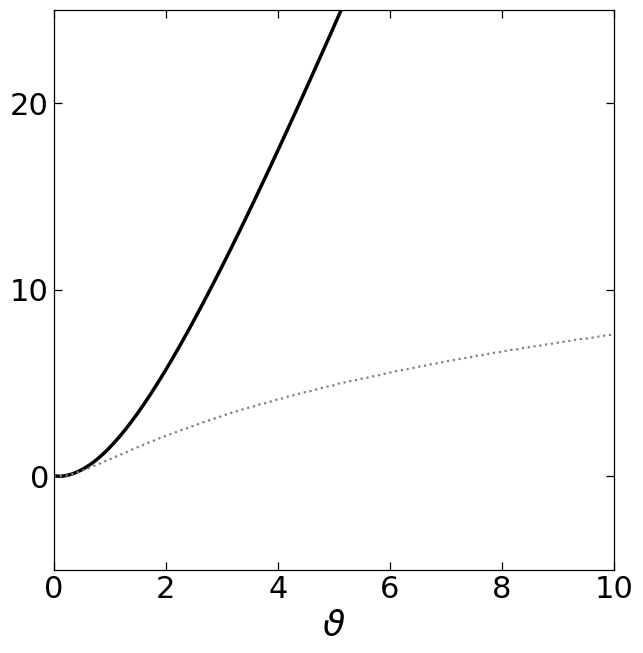

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Settings
# =====================================================

d = 6
theta_ref = 0.10

theta_grid = np.linspace(0.0, 10.0, 250)

N_MC = 150000
rng = np.random.default_rng(12345)

# White plot area, transparent outside
AXIS_FACE = "white"


# =====================================================
# Clayton copula sampler
# =====================================================

def simulate_clayton_d(theta, n, d, rng):
    """
    Simulate n observations from a d-dimensional Clayton copula.
    theta = 0 corresponds to independence.
    """

    if theta <= 1e-12:
        return rng.uniform(size=(n, d))

    W = rng.gamma(shape=1.0 / theta, scale=1.0, size=(n, 1))
    E = rng.exponential(scale=1.0, size=(n, d))

    U = (1.0 + E / W) ** (-1.0 / theta)

    return U


# =====================================================
# Stable d-dimensional Clayton log-density
# =====================================================

def clayton_log_density_d(U, theta):
    """
    Log-density of d-dimensional Clayton copula.

    c_theta(u)
      = prod_{j=1}^{d-1}(1 + j theta)
        * prod_i u_i^(-theta - 1)
        * (sum_i u_i^(-theta) - d + 1)^(-d - 1/theta)
    """

    if theta <= 1e-12:
        return np.zeros(U.shape[0])

    eps = 1e-14
    U = np.clip(U, eps, 1.0 - eps)

    n, d_local = U.shape

    log_U = np.log(U)

    log_const = np.sum(
        np.log(1.0 + theta * np.arange(1, d_local))
    )

    log_prod = (-theta - 1.0) * np.sum(log_U, axis=1)

    # Stable computation of:
    # log(sum_i u_i^(-theta) - d + 1)
    A = -theta * log_U
    M = np.max(A, axis=1)

    shifted_sum = np.sum(np.exp(A - M[:, None]), axis=1)
    correction = (1.0 - d_local) * np.exp(-M)

    inside = shifted_sum + correction
    inside = np.maximum(inside, 1e-300)

    log_S = M + np.log(inside)

    log_density = (
        log_const
        + log_prod
        + (-d_local - 1.0 / theta) * log_S
    )

    return log_density


# =====================================================
# Compute KL curves, unnormalized
# =====================================================

K_ref_to_theta = np.zeros_like(theta_grid)
K_theta_to_ref = np.zeros_like(theta_grid)

# Reuse one sample for K(0.10, vartheta)
U_ref = simulate_clayton_d(theta_ref, N_MC, d, rng)
log_ref_on_ref = clayton_log_density_d(U_ref, theta_ref)

for i, theta in enumerate(theta_grid):

    # Solid curve:
    # K(0.10, theta)
    log_theta_on_ref = clayton_log_density_d(U_ref, theta)

    K_ref_to_theta[i] = np.mean(
        log_ref_on_ref - log_theta_on_ref
    )

    # Dotted curve:
    # K(theta, 0.10)
    U_theta = simulate_clayton_d(theta, N_MC, d, rng)

    log_theta = clayton_log_density_d(U_theta, theta)
    log_ref = clayton_log_density_d(U_theta, theta_ref)

    K_theta_to_ref[i] = np.mean(
        log_theta - log_ref
    )

# Remove tiny Monte Carlo negatives around zero
K_ref_to_theta = np.maximum(K_ref_to_theta, 0.0)
K_theta_to_ref = np.maximum(K_theta_to_ref, 0.0)


# =====================================================
# Plot
# =====================================================

fig, ax = plt.subplots(figsize=(7, 7))

# Transparent outside background
fig.patch.set_alpha(0.0)

# White plot panel so black axes/curves remain visible
ax.set_facecolor(AXIS_FACE)

# Solid black:
# K(0.10, vartheta)
ax.plot(
    theta_grid,
    K_ref_to_theta,
    color="black",
    linewidth=2.5
)

# Dotted gray:
# K(vartheta, 0.10)
ax.plot(
    theta_grid,
    K_theta_to_ref,
    color="gray",
    linewidth=1.6,
    linestyle=":"
)

# Axis limits like the slide
ax.set_xlim(0, 10)
ax.set_ylim(-5, 25)

ax.set_xticks([0, 2, 4, 6, 8, 10])
ax.set_yticks([0, 10, 20])

ax.set_xlabel(r"$\vartheta$", fontsize=26)

# Square plotting box
ax.set_box_aspect(1)

ax.tick_params(
    direction="in",
    top=True,
    right=True,
    labelsize=22,
    length=6,
    width=0.9
)

for spine in ax.spines.values():
    spine.set_linewidth(0.9)
    spine.set_color("black")

plt.subplots_adjust(
    left=0.16,
    right=0.96,
    bottom=0.14,
    top=0.96
)

fig.savefig(
    "kl_clayton_6d_square_transparent_raw.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()